In [ ]:
import os
import re
import pandas as pd
from pathlib import Path

# ==============================================================================
# CONFIGURATION AND INPUT
# ==============================================================================
PEST_DIR = Path(r"c:\Python\Personal\kfm-ms\codes\pest")
MASTER_RUN_DIR = PEST_DIR / "master_run"

# Find the latest parameter file
import glob
par_files = sorted(glob.glob(str(PEST_DIR / "*inversion_level_*.par.csv")))
if not par_files:
    par_files = sorted(glob.glob(str(MASTER_RUN_DIR / "*inversion_level_*.par.csv")))

if not par_files:
    raise FileNotFoundError("[-] Error: No parameter ensemble CSV files found.")

PAR_FILE_PATH = Path(par_files[-1])
TRUTH_PATH = MASTER_RUN_DIR / "master_truth.csv"
OUTPUT_PATH = PEST_DIR / "optimized_pumping_rates.csv"

print(f"[+] Processing file: {PAR_FILE_PATH.name}")

# ==============================================================================
# DATA PARSING PIPELINE
# ==============================================================================
# Load data
df_pars = pd.read_csv(PAR_FILE_PATH, index_col=0)
df_truth = pd.read_csv(TRUTH_PATH)

# Isolate the optimized "base" row
if 'base' in df_pars.index:
    optimized_series = df_pars.loc['base']
else:
    print("[!] Warning: 'base' realization missing. Using ensemble average instead.")
    optimized_series = df_pars.mean(axis=0)

# Build map linking unique (r, c) coordinates to original well_ids
well_id_map = df_truth[['r', 'c', 'well_id']].drop_duplicates().set_index(['r', 'c'])['well_id'].to_dict()

# Regular expression to extract coordinates and time
token_regex = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")

parsed_records = []

for col_name, value in optimized_series.items():
    match = token_regex.search(col_name)
    if match:
        row_idx = int(match.group(1))
        col_idx = int(match.group(2))
        stress_period = int(match.group(3))
        
        # Look up well ID matching these coordinates
        well_id = well_id_map.get((row_idx, col_idx), -1)
        
        parsed_records.append({
            "well_id": well_id,
            "r": row_idx,
            "c": col_idx,
            "sp": stress_period,
            "q_optimized": round(float(value), 3)
        })

# Restructure into a standard data frame
df_optimized = pd.DataFrame(parsed_records)

# Sort logically by stress period then well identifier
df_optimized = df_optimized.sort_values(by=["sp", "well_id"]).reset_index(drop=True)

# Save result
df_optimized.to_csv(OUTPUT_PATH, index=False)
print(f"[+] Success! Clean table exported to: {OUTPUT_PATH}")
print("\nFirst 10 rows of optimized data:")
print(df_optimized.head(10).to_string(index=False))


## noptmax = 0 run

[+] Extracting active observation channels from control file...
[+] Total active observations: 6217
[+] Active observations plotted (above 0.1m): 6217
[+] Baseline initialization dashboard successfully completed.
[+] Output chart saved to -> C:\Python\Personal\kfm-ms\codes\pest\Baseline_Noptmax0_Diagnostic_Dashboard.png


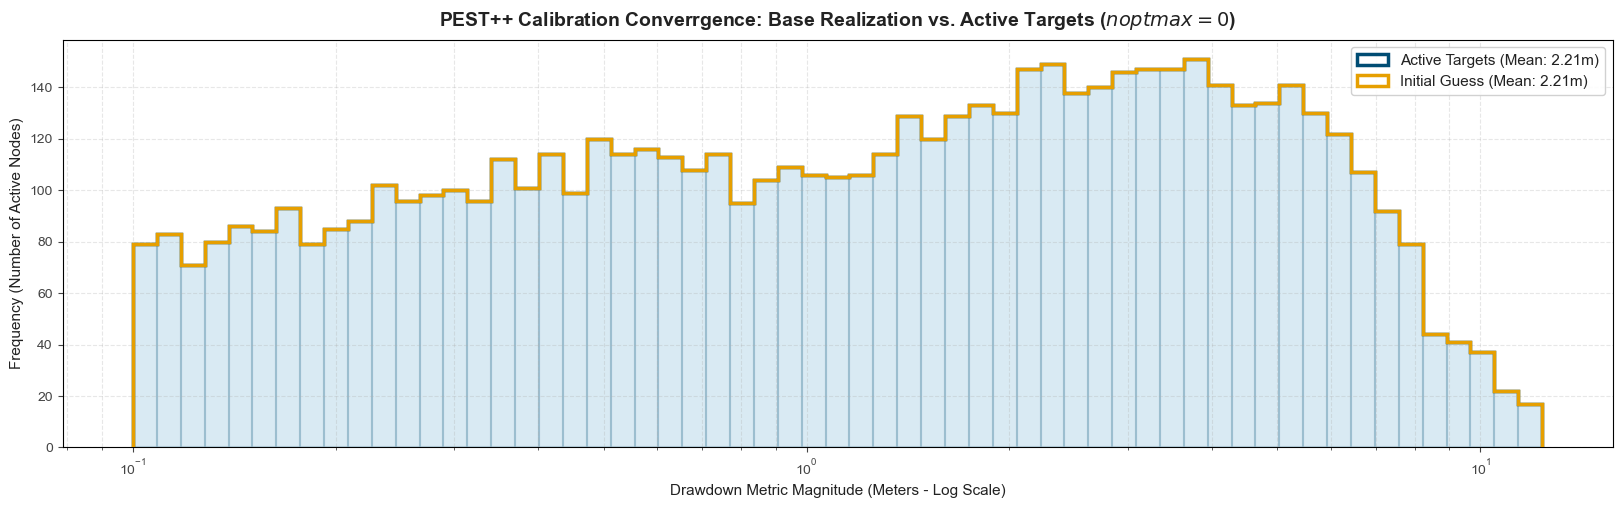

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import pyemu

# ==============================================================================
# DATA PATH CONFIGURATION
# ==============================================================================
PEST_DIR = r"C:\Python\Personal\kfm-ms\codes\pest"
MASTER_DIR = os.path.join(PEST_DIR, "master_run")
TARGET_OBS_PATH = os.path.join(PEST_DIR, "dummy_obs.csv")
MASTER_TRUTH_PATH = os.path.join(PEST_DIR, "master_truth.csv")
PST_CONTROL_PATH = os.path.join(PEST_DIR, "inversion_level_1.pst")

files_to_compare = {
    "Initial Guess": "inversion_level_1.obs_data.csv",
}

if not all(os.path.exists(p) for p in [TARGET_OBS_PATH, MASTER_TRUTH_PATH, PST_CONTROL_PATH]):
    raise FileNotFoundError(f"[-] Missing critical baseline or control files inside: {PEST_DIR}")

# 1. Load active PEST control weights and strip prefixes
print("[+] Extracting active observation channels from control file...")
pst = pyemu.Pst(PST_CONTROL_PATH)
active_obs = pst.observation_data[pst.observation_data["weight"] > 0.0].copy()

active_obs.index = active_obs.index.str.lower()
clean_active_names = [idx.split(":")[-1] if ":" in idx else idx for idx in active_obs.index]
active_obs_names = set(clean_active_names)

# 2. Load baseline targets and master grid truth
df_target = pd.read_csv(TARGET_OBS_PATH)
df_target["obsnme"] = df_target["obsnme"].astype(str).str.lower()
df_target = df_target.rename(columns={"obsval": "obsval_target"})

# Keep ONLY rows where the observation was actively weighted by PEST
df_target = df_target[df_target["obsnme"].isin(active_obs_names)].reset_index(drop=True)

df_truth = pd.read_csv(MASTER_TRUTH_PATH)
df_grid_map = df_truth.sort_values(by=['r', 'c', 'sp']).drop_duplicates(subset=['r', 'c']).reset_index(drop=True)

# Initialize master spatial dataframe tracking coordinates over time
df_spatial = df_target[["obsnme", "obsval_target"]].copy()

# Parse companion point IDs (cp) from strings to line up with matrix positions
df_spatial['point_num'] = df_spatial['obsnme'].str.extract(r'_cp(\d+)').fillna(0).astype(int)

# FIXED: Map row and column matrix indexes cleanly out of df_spatial tracking column
max_grid_nodes = len(df_grid_map)
df_spatial['r'] = df_spatial['point_num'].apply(lambda x: df_grid_map['r'].iloc[x % max_grid_nodes])
df_spatial['c'] = df_spatial['point_num'].apply(lambda x: df_grid_map['c'].iloc[x % max_grid_nodes])

spatial_columns = []
max_error_found = 0.1  

# 3. Parse the vertical structure of the obs_data summary file directly
for label, filename in files_to_compare.items():
    file_path = os.path.join(MASTER_DIR, filename)
    if not os.path.exists(file_path):
        print(f"[!] Warning: Missing {filename}. Skipping from layout.")
        continue
        
    df_obs_data = pd.read_csv(file_path)
    df_obs_data.columns = df_obs_data.columns.str.lower()
    
    # Clean the PstFrom prefixes from the observation name column
    df_obs_data["obsnme"] = df_obs_data["obsnme"].apply(lambda x: x.split(":")[-1].lower() if ":" in x else x.lower())
    
    # Isolate columns and rename to map predictions cleanly
    df_slice = df_obs_data[["obsnme", "obsval"]].rename(columns={"obsval": f"sim_base_{label}"})
    df_slice = df_slice[df_slice["obsnme"].isin(active_obs_names)]
    
    # Merge cleanly into tracking master coordinates dataframe
    df_spatial = pd.merge(df_spatial, df_slice, on="obsnme", how="left")
    
    err_col = f"abs_err_{label}"
    df_spatial[err_col] = (df_spatial[f"sim_base_{label}"] - df_spatial["obsval_target"]).abs()
    spatial_columns.append((label, err_col))
    
    max_error_found = max(max_error_found, df_spatial[err_col].max())

# ==============================================================================
# GRAPHICS DASHBOARD GENERATION
# ==============================================================================
fig = plt.figure(figsize=(20, 14))
plt.rcParams['font.family'] = 'sans-serif'

# Custom GridSpec: Top row spans fully, bottom row isolates a single clean centered map
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.3], hspace=0.3, wspace=0.15)
ax_top = fig.add_subplot(gs[0, :])

# --- TOP PANEL: BASELINE DISTRIBUTION MATCH ---
threshold = 0.1
sim_cols = [f"sim_base_{label}" for label, _ in spatial_columns if f"sim_base_{label}" in df_spatial.columns]

mask = df_spatial["obsval_target"] > threshold
for col in sim_cols:
    mask = mask | (df_spatial[col] > threshold)

df_filtered = df_spatial[mask]
print(f"[+] Total active observations: {len(df_spatial)}")
print(f"[+] Active observations plotted (above {threshold}m): {len(df_filtered)}")

all_vals = [df_filtered["obsval_target"].values] + [df_filtered[c].values for c in sim_cols]
min_val = max(min(np.min(v) for v in all_vals if len(v) > 0), 1e-3)
max_val = max(np.max(v) for v in all_vals if len(v) > 0)
bins = np.logspace(np.log10(min_val), np.log10(max_val), 60)

target_data = df_filtered["obsval_target"].values
ax_top.hist(target_data, bins=bins, color='#0072B2', alpha=0.15, edgecolor='#004C73', lw=1.5)
ax_top.hist(target_data, bins=bins, histtype='step', color='#004C73', lw=2.5, label=f'Active Targets (Mean: {target_data.mean():.2f}m)', zorder=2)

for label, _ in spatial_columns:
    col = f"sim_base_{label}"
    if col in df_filtered.columns:
        sim_data = df_filtered[col].values
        ax_top.hist(sim_data, bins=bins, histtype='step', color='#E69F00', lw=2.5, label=f'{label} (Mean: {sim_data.mean():.2f}m)', zorder=3)

ax_top.set_xscale('log')
ax_top.set_title("PEST++ Calibration Converrgence: Base Realization vs. Active Targets ($noptmax=0$)", fontsize=14, fontweight='bold', pad=10)
ax_top.set_xlabel("Drawdown Metric Magnitude (Meters - Log Scale)", fontsize=11)
ax_top.set_ylabel("Frequency (Number of Active Nodes)", fontsize=11)
ax_top.grid(True, which="both", linestyle="--", alpha=0.3, zorder=1)
ax_top.legend(loc='upper right', framealpha=0.9, facecolor='white', fontsize=11)

output_filename = os.path.join(PEST_DIR, "Baseline_Noptmax0_Diagnostic_Dashboard.png")
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"[+] Baseline initialization dashboard successfully completed.")
print(f"[+] Output chart saved to -> {output_filename}")
plt.show()


## multi-iteration runs

[+] Extracting active observation channels from control file...


C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_34260\3847543282.py:69: DtypeWarning: Columns (0: real_name) have mixed types. Specify dtype option on import or set low_memory=False.
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_34260\3847543282.py:69: DtypeWarning: Columns (0: real_name) have mixed types. Specify dtype option on import or set low_memory=False.
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_34260\3847543282.py:69: DtypeWarning: Columns (0: real_name) have mixed types. Specify dtype option on import or set low_memory=False.


[+] Total active observations: 7863
[+] Active observations plotted (above 0.1m): 7141
[+] Base-realization timeline dashboard executed successfully.
[+] Visualization asset saved to -> C:\Python\Personal\kfm-ms\codes\pest\Spatial_Mismatch_Timeline_Dashboard.png


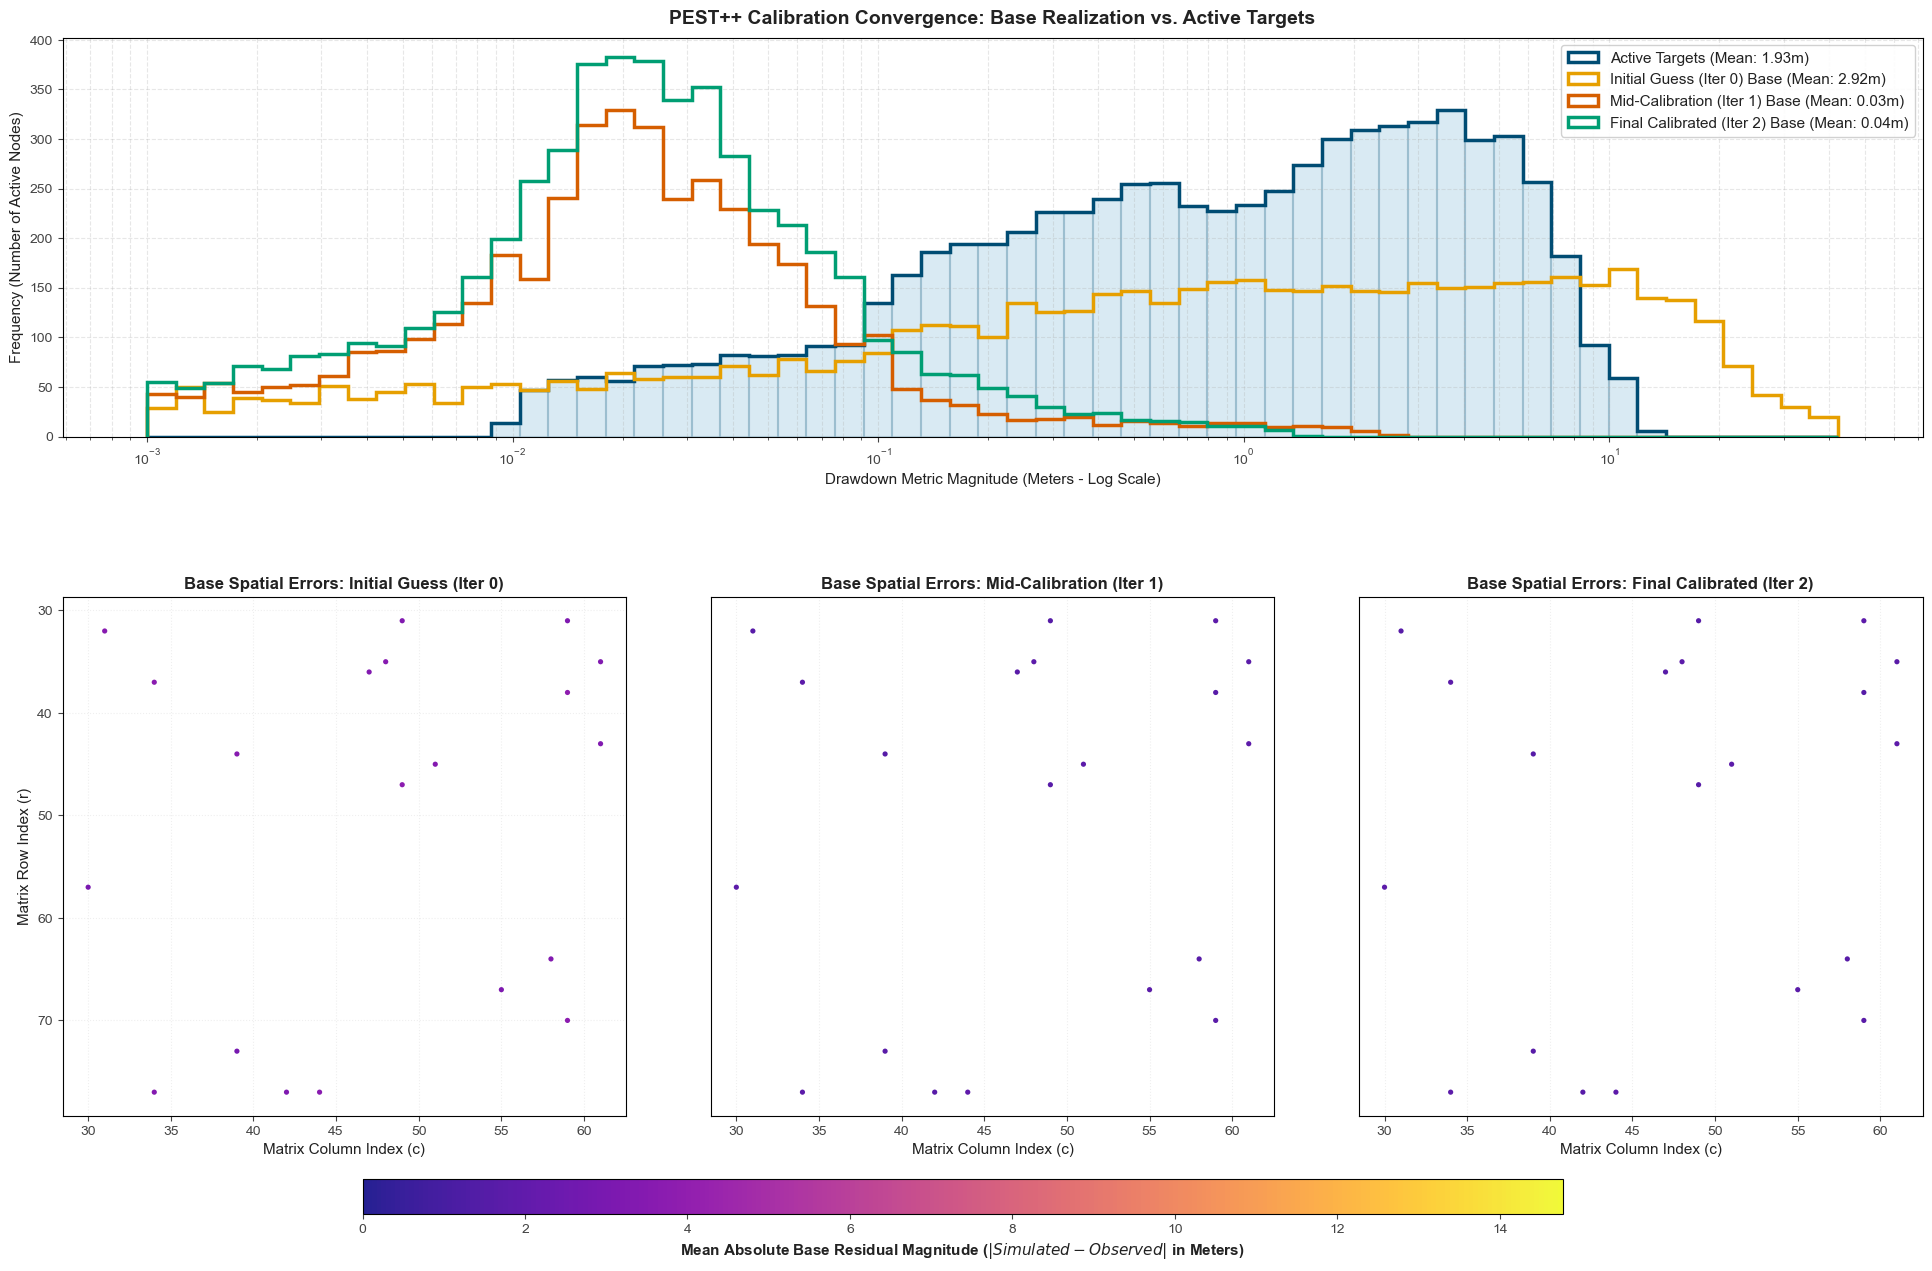

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import pyemu

# ==============================================================================
# DATA PATH CONFIGURATION
# ==============================================================================
PEST_DIR = r"C:\Python\Personal\kfm-ms\codes\pest"
MASTER_DIR = os.path.join(PEST_DIR, "master_run")
TARGET_OBS_PATH = os.path.join(PEST_DIR, "dummy_obs.csv")
MASTER_TRUTH_PATH = os.path.join(PEST_DIR, "master_truth.csv")
PST_CONTROL_PATH = os.path.join(PEST_DIR, "inversion_level_1.pst")

files_to_compare = {
    "Initial Guess (Iter 0)": "inversion_level_1.0.obs.csv",
    "Mid-Calibration (Iter 1)": "inversion_level_1.1.obs.csv",
    "Final Calibrated (Iter 2)": "inversion_level_1.2.obs.csv"
}

if not all(os.path.exists(p) for p in [TARGET_OBS_PATH, MASTER_TRUTH_PATH, PST_CONTROL_PATH]):
    raise FileNotFoundError(f"[-] Missing critical baseline or control files inside: {PEST_DIR}")

# 1. Load active PEST control weights and strip prefixes
print("[+] Extracting active observation channels from control file...")
pst = pyemu.Pst(PST_CONTROL_PATH)
active_obs = pst.observation_data[pst.observation_data["weight"] > 0.0].copy()

active_obs.index = active_obs.index.str.lower()
clean_active_names = [idx.split(":")[-1] if ":" in idx else idx for idx in active_obs.index]
active_obs_names = set(clean_active_names)

# 2. Load baseline targets and master grid truth
df_target = pd.read_csv(TARGET_OBS_PATH)
df_target["obsnme"] = df_target["obsnme"].astype(str).str.lower()
df_target = df_target.rename(columns={"obsval": "obsval_target"})

# Keep ONLY rows where the observation was actively weighted by PEST
df_target = df_target[df_target["obsnme"].isin(active_obs_names)].reset_index(drop=True)

df_truth = pd.read_csv(MASTER_TRUTH_PATH)
df_grid_map = df_truth.sort_values(by=['r', 'c', 'sp']).drop_duplicates(subset=['r', 'c']).reset_index(drop=True)

# Initialize master spatial dataframe tracking coordinates over time
df_spatial = df_target[["obsnme", "obsval_target"]].copy()

# Parse companion point IDs (cp) from strings to line up with matrix positions
df_spatial['point_num'] = df_spatial['obsnme'].str.extract(r'_cp(\d+)').fillna(0).astype(int)

# Map row and column matrix indexes
max_grid_nodes = len(df_grid_map)
df_spatial['r'] = df_spatial['point_num'].apply(lambda x: df_grid_map['r'].iloc[x % max_grid_nodes])
df_spatial['c'] = df_spatial['point_num'].apply(lambda x: df_grid_map['c'].iloc[x % max_grid_nodes])

# Containers for loops
spatial_columns = []
max_error_found = 0.1  

# 3. Loop through iteration files to extract the 'base' realization explicitly
for label, filename in files_to_compare.items():
    file_path = os.path.join(MASTER_DIR, filename)
    if not os.path.exists(file_path):
        print(f"[!] Warning: Missing {filename}. Skipping from timeline matrix.")
        continue
        
    df_ensemble = pd.read_csv(file_path)
    df_ensemble.columns = df_ensemble.columns.str.lower()
    
    # Identify realization tracking column dynamically
    label_cols = [c for c in df_ensemble.columns if 'real' in c or 'name' in c or 'stage' in c]
    
    if label_cols:
        id_col = label_cols[0]
        # Locate the exact 'base' row case-insensitively
        df_base_row = df_ensemble[df_ensemble[id_col].astype(str).str.lower() == 'base']
        if df_base_row.empty:
            df_base_row = df_ensemble.iloc[[0]] # Fallback to first row if string literal isn't present
            print(f"[!] 'base' row missing in {filename}. Falling back to row index 0.")
    else:
        df_base_row = df_ensemble.iloc[[0]]
        print(f"[!] No label metadata in {filename}. Falling back to row index 0.")
        
    # Unwrap horizontal observation columns into vertical dataframe row mappings via melt
    obs_cols = [c for c in df_ensemble.columns if c not in label_cols]
    df_melted = df_base_row.melt(value_vars=obs_cols, var_name="obsnme", value_name=f"sim_base_{label}")
    
    # Strip PstFrom prefix strings from the index name column
    df_melted["obsnme"] = df_melted["obsnme"].apply(lambda x: x.split(":")[-1].lower() if ":" in x else x.lower())
    
    # Filter to look strictly at our active observation subset
    df_melted = df_melted[df_melted["obsnme"].isin(active_obs_names)]
    
    # Merge cleanly into our tracking master data structure
    df_spatial = pd.merge(df_spatial, df_melted, on="obsnme", how="left")
    
    err_col = f"abs_err_{label}"
    df_spatial[err_col] = (df_spatial[f"sim_base_{label}"] - df_spatial["obsval_target"]).abs()
    spatial_columns.append((label, err_col))
    
    max_error_found = max(max_error_found, df_spatial[err_col].max())

# ==============================================================================
# 4-PANEL COMPOSITE DASHBOARD INITIALIZATION
# ==============================================================================
fig = plt.figure(figsize=(24, 14))
plt.rcParams['font.family'] = 'sans-serif'

gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.3], hspace=0.35, wspace=0.15)
ax_top = fig.add_subplot(gs[0, :])

# --- TOP PANEL: SYNCHRONIZED MULTI-ITERATION FILTERING MASK ---
threshold = 0.1
sim_cols = [f"sim_base_{label}" for label, _ in spatial_columns if f"sim_base_{label}" in df_spatial.columns]

mask = df_spatial["obsval_target"] > threshold
for col in sim_cols:
    mask = mask | (df_spatial[col] > threshold)

df_filtered = df_spatial[mask]
print(f"[+] Total active observations: {len(df_spatial)}")
print(f"[+] Active observations plotted (above {threshold}m): {len(df_filtered)}")

# Establish unified logarithmic bin boundaries across all datasets
all_vals = [df_filtered["obsval_target"].values] + [df_filtered[c].values for c in sim_cols]
min_val = max(min(np.min(v) for v in all_vals if len(v) > 0), 1e-3)
max_val = max(np.max(v) for v in all_vals if len(v) > 0)
bins = np.logspace(np.log10(min_val), np.log10(max_val), 60)

# 1. Plot True Target Field Observations (Filled baseline block)
target_data = df_filtered["obsval_target"].values
ax_top.hist(target_data, bins=bins, color='#0072B2', alpha=0.15, edgecolor='#004C73', lw=1.5)
ax_top.hist(target_data, bins=bins, histtype='step', color='#004C73', lw=2.5, label=f'Active Targets (Mean: {target_data.mean():.2f}m)', zorder=2)

# 2. Plot Simulated Base Realizations matching standalone colors
color_map = {
    "Initial Guess (Iter 0)": "#E69F00",
    "Mid-Calibration (Iter 1)": "#D55E00",
    "Final Calibrated (Iter 2)": "#009E73"
}

for label, _ in spatial_columns:
    col = f"sim_base_{label}"
    if col in df_filtered.columns:
        sim_data = df_filtered[col].values
        ax_top.hist(sim_data, bins=bins, histtype='step', color=color_map.get(label, '#333333'),
                 lw=2.5, label=f'{label} Base (Mean: {sim_data.mean():.2f}m)', zorder=3)

ax_top.set_xscale('log')
ax_top.set_title("PEST++ Calibration Convergence: Base Realization vs. Active Targets", fontsize=14, fontweight='bold', pad=10)
ax_top.set_xlabel("Drawdown Metric Magnitude (Meters - Log Scale)", fontsize=11)
ax_top.set_ylabel("Frequency (Number of Active Nodes)", fontsize=11)
ax_top.grid(True, which="both", linestyle="--", alpha=0.3, zorder=1)
ax_top.legend(loc='upper right', framealpha=0.9, facecolor='white', fontsize=11)

# --- BOTTOM ROW: CRUNCHED SPATIAL PIXEL TIMELINE SUBPLOTS ---
color_norm = Normalize(vmin=0.0, vmax=max_error_found * 0.35) 

for idx, (label, err_col) in enumerate(spatial_columns):
    ax_sub = fig.add_subplot(gs[1, idx])
    
    # Render background structural grid framework softly
    ax_sub.scatter(df_grid_map['c'], df_grid_map['r'], c='#333333', alpha=0.02, s=6, zorder=1)
    
    # Aggregate absolute mismatch values over stress periods for spatial mapping
    df_grouped_error = df_spatial.groupby(['r', 'c'])[err_col].mean().reset_index()
    
    scatter_timeline = ax_sub.scatter(
        df_grouped_error['c'], df_grouped_error['r'], 
        c=df_grouped_error[err_col], cmap='plasma', norm=color_norm,
        s=14, alpha=0.9, linewidths=0, zorder=2
    )
    
    ax_sub.set_title(f"Base Spatial Errors: {label}", fontsize=12, fontweight='bold')
    ax_sub.grid(True, linestyle=":", alpha=0.2)
    ax_sub.invert_yaxis()
    
    if idx == 0:
        ax_sub.set_ylabel("Matrix Row Index (r)", fontsize=11)
    else:
        ax_sub.set_yticks([]) 
        
    ax_sub.set_xlabel("Matrix Column Index (c)", fontsize=11)

# Attach single colorbar track axis at base
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.025])
cbar = fig.colorbar(scatter_timeline, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Mean Absolute Base Residual Magnitude ($|Simulated - Observed|$ in Meters)", fontsize=11, fontweight='bold')

output_filename = os.path.join(PEST_DIR, "Spatial_Mismatch_Timeline_Dashboard.png")
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"[+] Base-realization timeline dashboard executed successfully.")
print(f"[+] Visualization asset saved to -> {output_filename}")
plt.show()


[+] Output complete: Vector asset available at -> c:\Python\Personal\kfm-ms\codes\pest\Level1_Ensemble_Match.svg


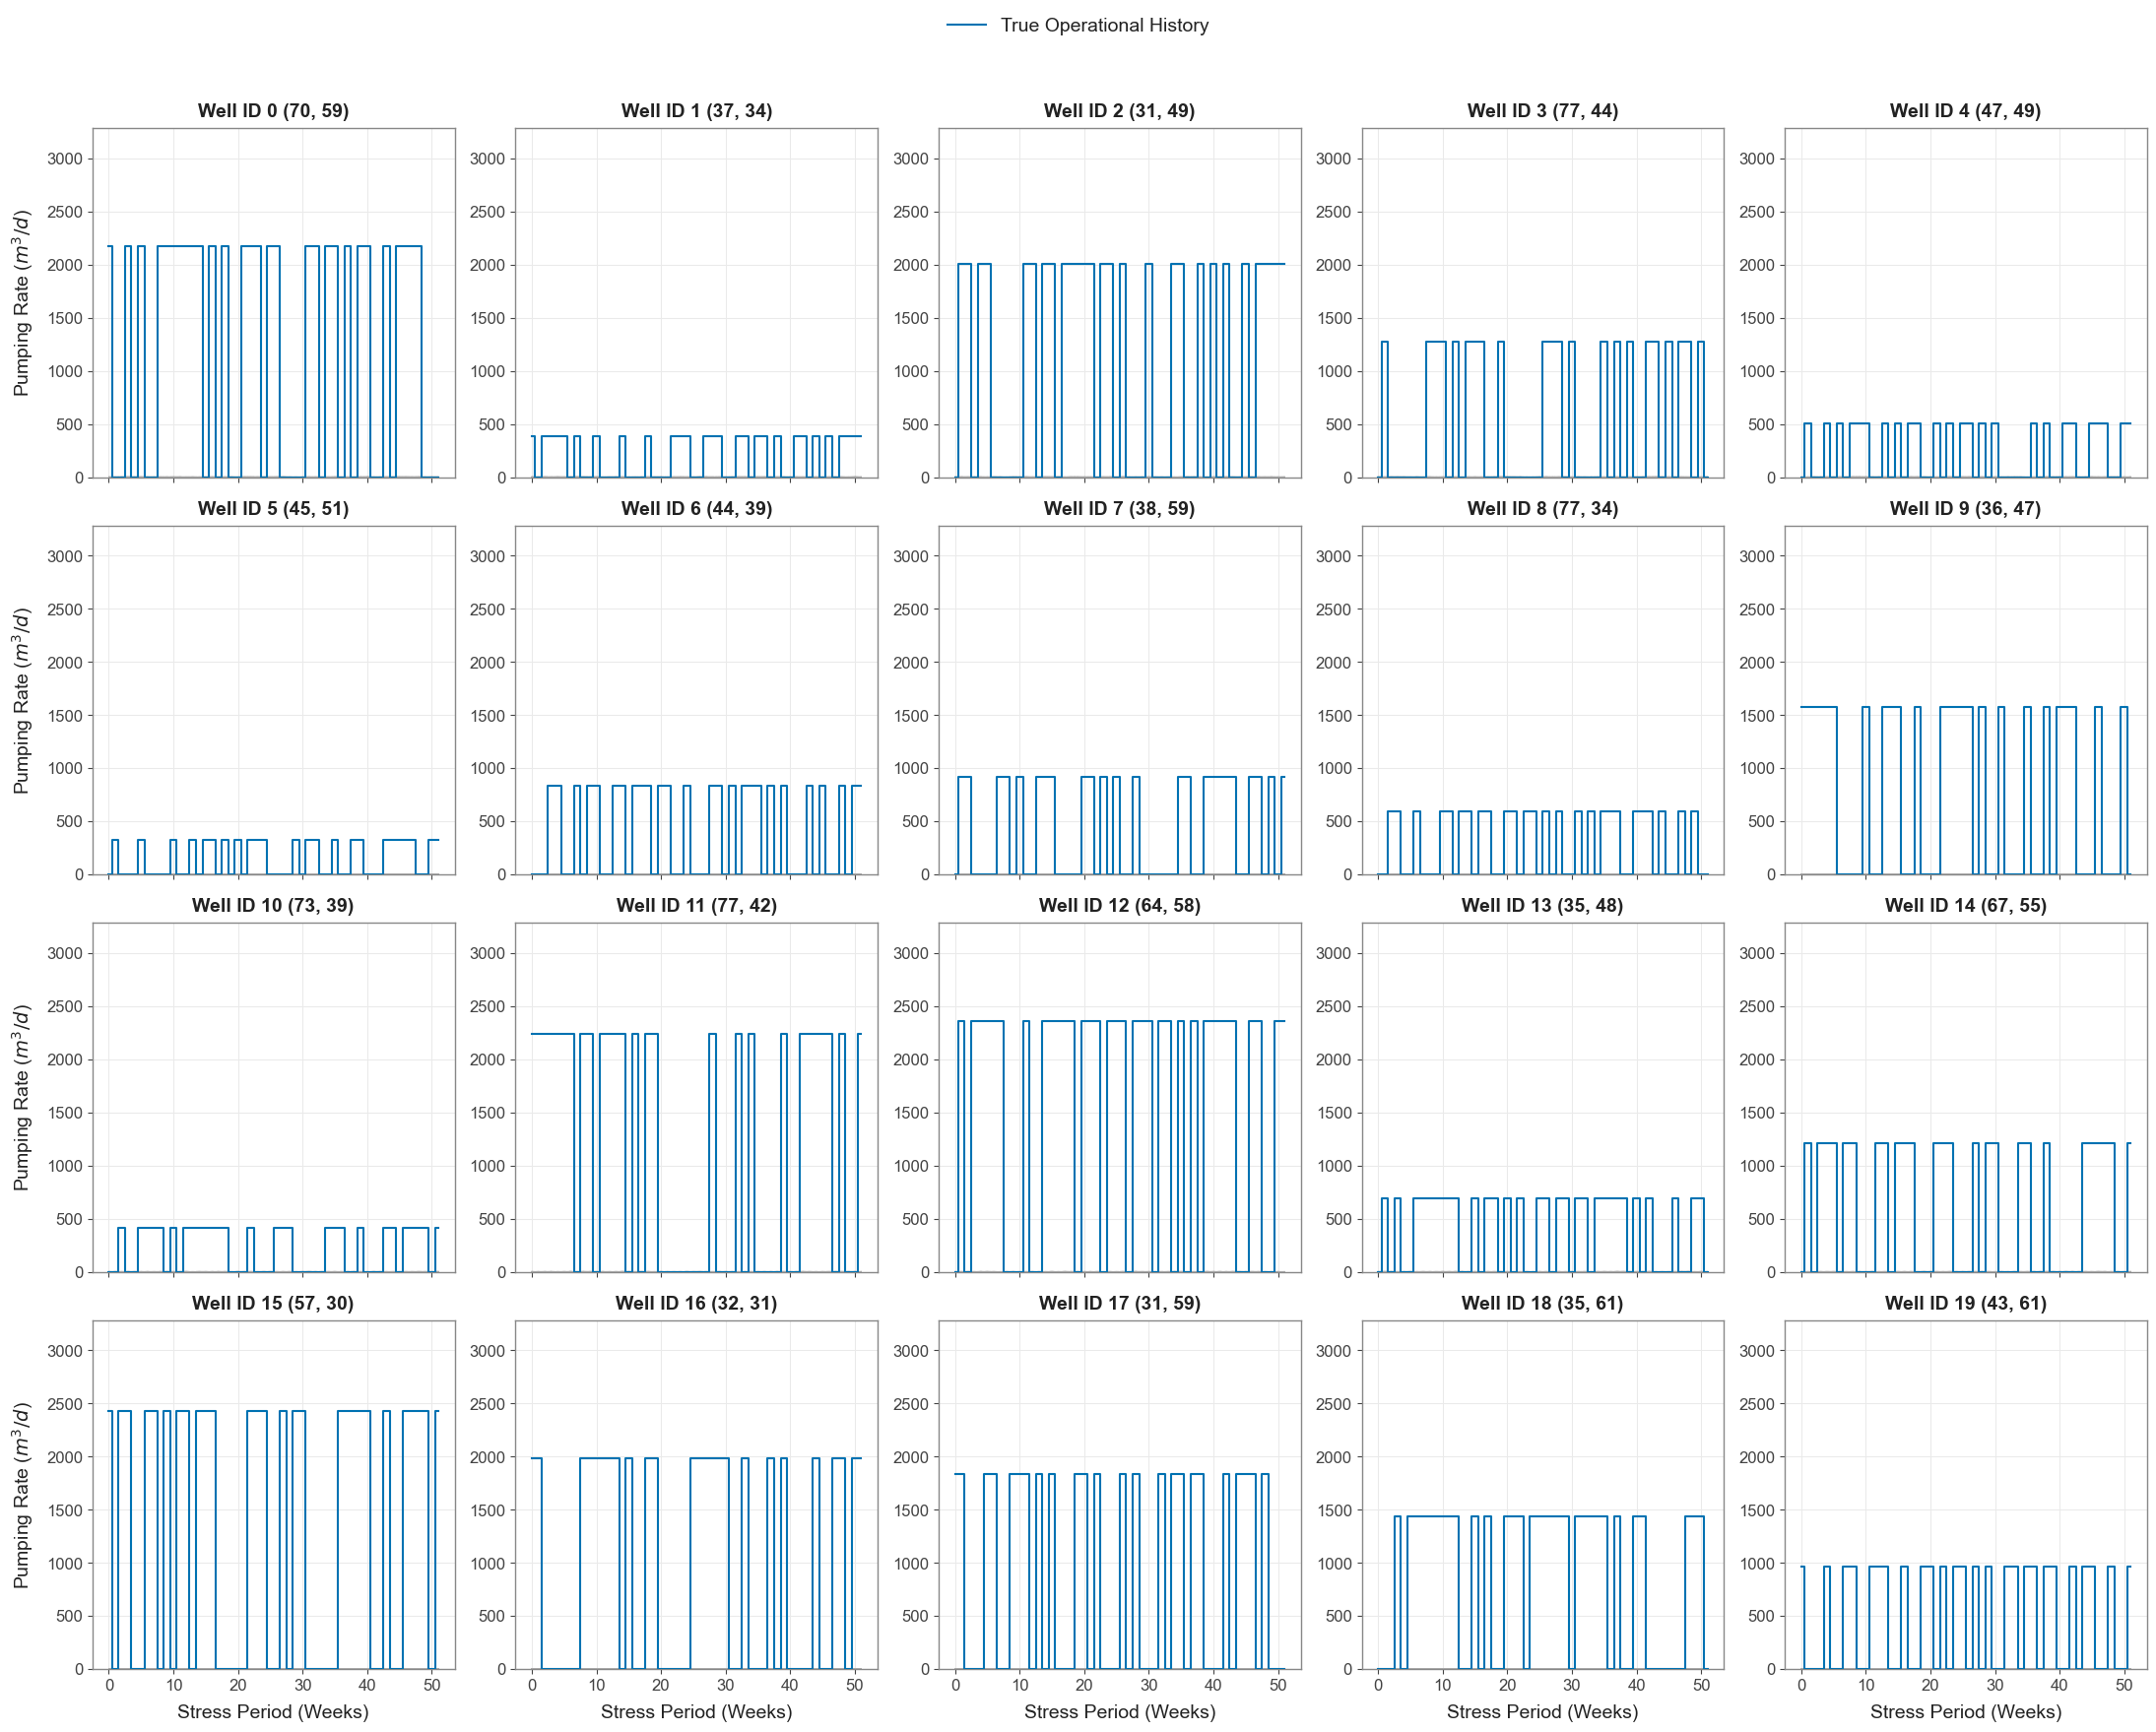

In [ ]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==============================================================================
# ENVIRONMENT AND ENVIRONMENT RESOLUTION
# ==============================================================================
PEST_DIR = Path(r"c:\Python\Personal\kfm-ms\codes\pest")
MASTER_RUN_DIR = PEST_DIR / "master_run"

search_pattern = "*inversion_level_*.par.csv"
fallback_pattern = "*inversion_level_*.*par*.csv"

par_files = sorted(glob.glob(str(PEST_DIR / search_pattern)))
if not par_files:
    par_files = sorted(glob.glob(str(PEST_DIR / fallback_pattern)))
if not par_files:
    par_files = sorted(glob.glob(str(MASTER_RUN_DIR / search_pattern)))
if not par_files:
    par_files = sorted(glob.glob(str(MASTER_RUN_DIR / fallback_pattern)))

if not par_files:
    print(f"[-] Directory contents for {PEST_DIR}: {os.listdir(PEST_DIR) if PEST_DIR.exists() else 'Dir missing'}")
    raise FileNotFoundError(
        f"[-] Error: No parameter ensemble CSV files found matching patterns in:\n"
        f"    -> {PEST_DIR}\n"
        f"    -> {MASTER_RUN_DIR}"
    )

final_par_path = Path(par_files[-1])

# Robust lookup for master_truth.csv across potential run directories
truth_path = MASTER_RUN_DIR / "master_truth.csv"
if not truth_path.exists():
    truth_path = PEST_DIR / "master_truth.csv"

# ==============================================================================
# GLOBAL STYLING & GRAPHICS CONFIGURATION
# ==============================================================================
FONT_SIZE = 14  
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['text.color'] = '#222222'
mpl.rcParams['axes.labelcolor'] = '#222222'
mpl.rcParams['xtick.color'] = '#444444'
mpl.rcParams['ytick.color'] = '#444444'

# ==============================================================================
# DATA INGESTION & PIPELINE ASSEMBLY
# ==============================================================================
df_truth = pd.read_csv(truth_path)
df_pars = pd.read_csv(final_par_path, index_col=0)

# Normalize both indices and column text structures to clean lowercase strings
df_pars.index = df_pars.index.astype(str).str.lower()
df_pars.columns = df_pars.columns.astype(str).str.lower()

unique_wells = df_truth.sort_values("well_id")[['well_id', 'r', 'c']].drop_duplicates()
num_wells = len(unique_wells)

num_cols = 5
num_rows = int(np.ceil(num_wells / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(22, num_rows * 4.5), sharex=True)
axes = axes.flatten()

global_q_max = df_truth['q'].max() if df_truth['q'].max() > 0 else 100.0
y_limit = global_q_max * 1.35  

# ==============================================================================
# RESPONSIVE RENDERING ENGINE LOOP
# ==============================================================================
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    w_id, r, c = int(row.well_id), int(row.r), int(row.c)
    
    well_tag = f"r:{r}_c:{c}"
    
    ax.set_facecolor('#FFFFFF')
    ax.grid(True, color="#EAEAEA", linestyle="-", linewidth=0.75, zorder=1)
    
    for spine in ax.spines.values():
        spine.set_color('#888888')
        spine.set_linewidth(1.0)
    
    # Extract columns using your working text match rule
    well_cols = [col for col in df_pars.columns if well_tag in col]
    
    # FIXED: Lowercase "sp:" split safely parses index periods from longnames=True format
    well_cols.sort(key=lambda x: int(''.join(filter(str.isdigit, x.split("_sp:")[-1]))))
    
    if not well_cols:
        print(f"[!] Warning: No columns matched token query string '{well_tag}' for Well {w_id}")
        continue

    # 1. Plot background realizations (gray lines)
    for real in df_pars.index:
        if real not in ['base']:
            ax.plot(df_pars.loc[real, well_cols].values, color="#B0B0B0", alpha=0.08, linewidth=0.6, zorder=2)
        
    # 2. Plot True pumping history profile
    truth_q = df_truth[df_truth.well_id == w_id].sort_values("sp")['q'].values
    ax.step(range(len(truth_q)), truth_q, label="True Operational History" if i == 0 else "", 
            color='#0072B2', linewidth=1.5, where="mid", zorder=10)
    
    # 3. Plot reference Base calculation curve
    if 'base' in df_pars.index:
        base_q = df_pars.loc['base', well_cols].values
        ax.plot(base_q, label="Optimized Base Selection" if i == 0 else "", 
                color='#E69F00', linestyle='--', linewidth=2.0, zorder=11)
    
    ax.set_title(f"Well ID {w_id} ({r}, {c})", fontsize=FONT_SIZE, fontweight='bold', pad=8)
    ax.set_ylim(0, y_limit)
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE - 2, colors='#444444')
    
    if i % num_cols == 0:
        ax.set_ylabel("Pumping Rate ($m^3/d$)", fontsize=FONT_SIZE, labelpad=8)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period (Weeks)", fontsize=FONT_SIZE, labelpad=8)

for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# ==============================================================================
# INTEGRATED MASTER LEGEND ASSEMBLY
# ==============================================================================
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles, labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.98), 
        ncol=3, # Expanded to accommodate all 3 line assets neatly
        facecolor='#FFFFFF', 
        edgecolor='none', 
        framealpha=1.0, 
        fontsize=FONT_SIZE
    )

plt.tight_layout(rect=[0, 0, 1, 0.93])

output_filename = PEST_DIR / "Level1_Ensemble_Match.svg"
plt.savefig(str(output_filename), dpi=300, bbox_inches='tight')
print(f"[+] Output complete: Vector asset available at -> {output_filename}")
plt.show()
